Anomaly Detection Assignment

Question 1: What is Anomaly Detection? Explain its types

Answer:

  Anomaly Detection is the process of identifying data points that significantly differ from the majority of the data. These unusual observations are called anomalies or outliers and may indicate errors, fraud, or rare events.

  Types of Anomalies:

  1. Point Anomalies (Global Outliers)  

  A single data point is far from the rest.  

  Example: A taxi fare of ₹10,000 when most fares are ₹100–₹500.  

  2. Contextual Anomalies (Conditional Outliers)  

  A data point is abnormal in a specific context (e.g., time or location).  

  Example: High electricity usage at 3 AM (unusual at night, normal in daytime).  

  3. Collective Anomalies  

  A group of data points is abnormal together, even if individual points are not.  

  Example: Continuous small spikes in server traffic indicating a cyber attack.  



Question 2: Comparison of Isolation Forest, DBSCAN, and LOF

Answer:

| Method                         | Approach                 | Key Idea                                       | Suitable Use Cases                    |
| ------------------------------ | ------------------------ | ---------------------------------------------- | ------------------------------------- |
| **Isolation Forest**           | Tree-based               | Isolates anomalies quickly using random splits | High-dimensional data, large datasets |
| **DBSCAN**                     | Density-based clustering | Points in low-density areas are anomalies      | Spatial data, clustering with noise   |
| **Local Outlier Factor (LOF)** | Density-based            | Compares local density with neighbors          | Detecting local anomalies             |




Question 3: Key Components of Time Series

Answer:

  1. Trend  

    Long-term upward or downward movement  

    Example: Increasing airline passengers over years  

  2. Seasonality  

    Regular repeating pattern  

    Example: Higher sales during festivals  

  3. Cyclic Component  

    Irregular long-term fluctuations  

    Example: Economic cycles (boom/recession)  

  4. Residual (Noise)  

    Random variation not explained by other components  

    Example: Unexpected spike due to an event  



Question 4: Stationarity in Time Series

Answer:

  A time series is stationary if its statistical properties (mean, variance) remain constant over time.

  Testing Stationarity:

  1. ADF Test (Augmented Dickey-Fuller)  

    Null hypothesis: non-stationary  

    If p-value < 0.05 → stationary  

  Transformations:

    Differencing (most common)  

    Log transformation  

    Seasonal differencing  

    Detrending  



Question 5: AR, MA, ARIMA, SARIMA, SARIMAX

Answer:

| Model                   | Structure                   | Use Case                         |
| ----------------------- | --------------------------- | -------------------------------- |
| **AR (AutoRegressive)** | Depends on past values      | Short-term forecasting           |
| **MA (Moving Average)** | Depends on past errors      | Noise smoothing                  |
| **ARIMA**               | AR + MA + differencing      | Non-stationary data              |
| **SARIMA**              | ARIMA + seasonality         | Seasonal data                    |
| **SARIMAX**             | SARIMA + external variables | Forecast with exogenous features |



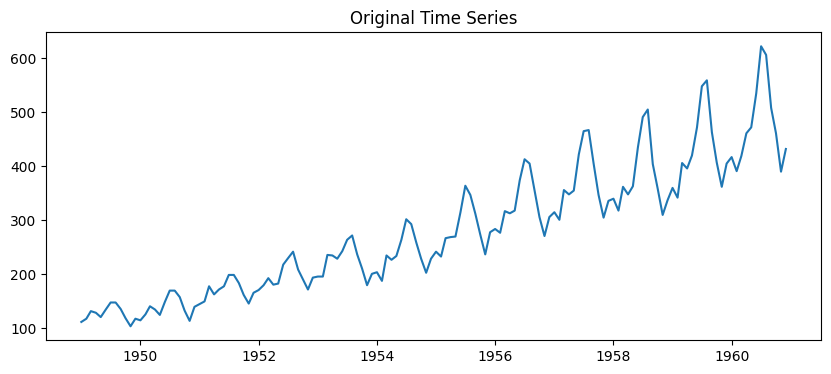

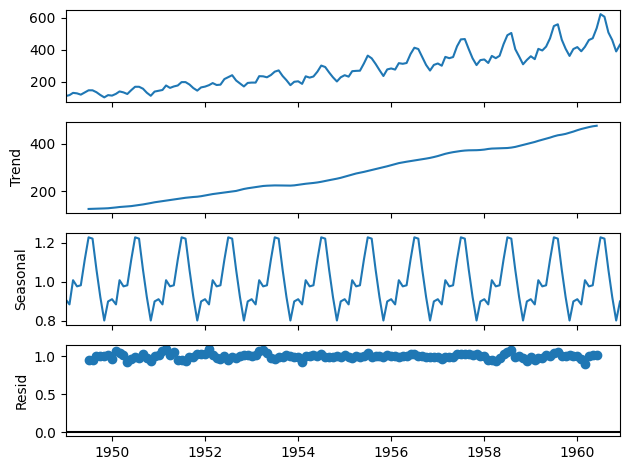

In [7]:
#Question 6: Time Series Decomposition (AirPassengers)
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
data = pd.read_csv('/content/sample_data/AirPassengers (1).csv', parse_dates=['date'], index_col='date')

# Plot original series
plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Original Time Series")
plt.show()

# Decompose
decomposition = seasonal_decompose(data, model='multiplicative')

# Plot decomposition
decomposition.plot()
plt.show()

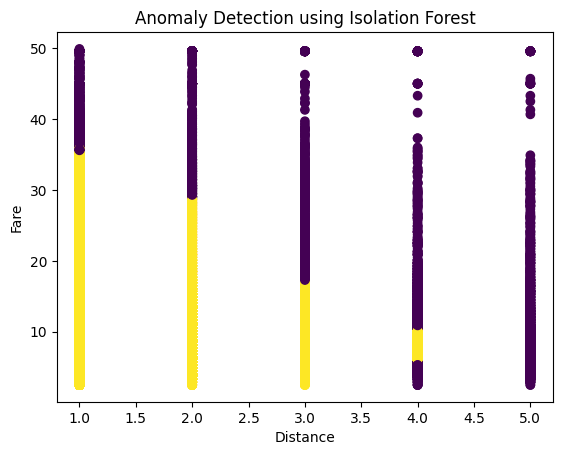

In [13]:
# Question 7: Isolation Forest on Taxi Fare Dataset
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/NYCTaxiFares.csv')  # Make sure this CSV exists
# Example dataset (simplified)
X = df[['fare_amount', 'passenger_count']]

model = IsolationForest(contamination=0.05)
df['anomaly'] = model.fit_predict(X)

# Plot
plt.scatter(df['passenger_count'], df['fare_amount'], c=df['anomaly'])
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Anomaly Detection using Isolation Forest")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


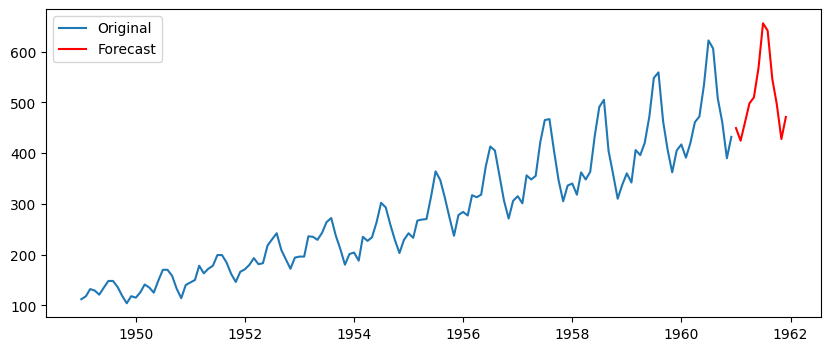

In [8]:
# Question 8: SARIMA Forecast (AirPassengers)
import statsmodels.api as sm

# Fit SARIMA model
model = sm.tsa.statespace.SARIMAX(data,
                                 order=(1,1,1),
                                 seasonal_order=(1,1,1,12))
results = model.fit()

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
pred = forecast.predicted_mean

# Plot
plt.figure(figsize=(10,4))
plt.plot(data, label='Original')
plt.plot(pred, label='Forecast', color='red')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


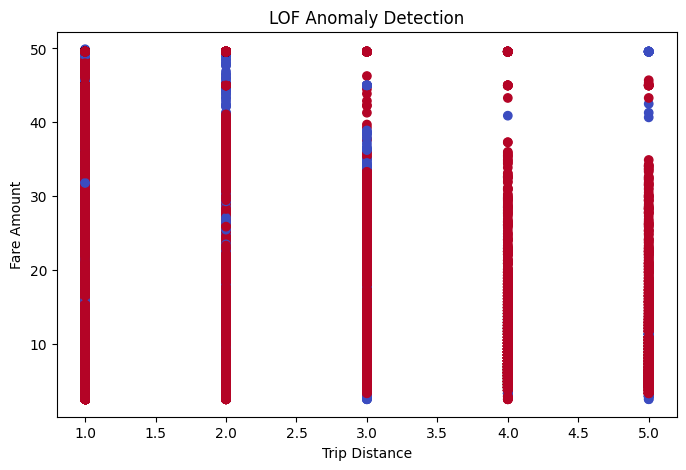

In [12]:
# Question 9: Local Outlier Factor (LOF)
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

# Example numerical dataset
df = pd.read_csv('/content/sample_data/NYCTaxiFares.csv')  # Make sure this CSV exists
X = df[['fare_amount', 'passenger_count']]  # Select numeric columns for LOF

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20)
df['lof'] = lof.fit_predict(X)

# Visualize anomalies
plt.figure(figsize=(8,5))
plt.scatter(X['passenger_count'], X['fare_amount'], c=df['lof'], cmap='coolwarm')
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("LOF Anomaly Detection")
plt.show()

Question 10: Real-Time Data Science Workflow (Power Grid)

Answer:

1. Anomaly Detection in Streaming Data

Use Isolation Forest for real-time detection (fast, scalable)  

Optionally combine with LOF for local anomalies  

Process data in mini-batches (streaming pipeline)  

2. Time Series Model

Use SARIMAX  

Captures seasonality (daily/weekly)  

Includes exogenous variables (weather, region)  



3. Validation & Monitoring

Metrics:  

RMSE, MAE for forecasting  

Drift detection:  

Monitor changes in distribution  

Retraining:  

Periodically update model  



4. Business Impact

Detect abnormal spikes → prevent outages  

Forecast demand → optimize energy supply  

Reduce costs → better load balancing  

Improve reliability → real-time alerts  



Sample Code (Simplified Pipeline)




In [15]:
import pandas as pd
import numpy as np

# Generate timestamps every 15 minutes
timestamps = pd.date_range(start='2026-01-01', periods=96*7, freq='15T')  # 7 days

# Simulate regions
regions = ['North', 'South', 'East', 'West']
region = np.random.choice(regions, len(timestamps))

# Simulate weather: temperature and humidity
temperature = np.random.normal(25, 5, len(timestamps))
humidity = np.random.uniform(30, 80, len(timestamps))

# Simulate energy usage with some spikes
energy_usage = np.random.normal(200, 50, len(timestamps))
spike_indices = np.random.choice(len(timestamps), 10)
energy_usage[spike_indices] *= 2  # create anomalies

# Create DataFrame
df = pd.DataFrame({
    'timestamp': timestamps,
    'region': region,
    'temperature': temperature,
    'humidity': humidity,
    'energy_usage': energy_usage
})

df.head()

/tmp/ipykernel_911/4105683479.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start='2026-01-01', periods=96*7, freq='15T')  # 7 days


,timestamp,region,temperature,humidity,energy_usage
0,2026-01-01 00:00:00,North,29.930924,40.261088,238.542133
1,2026-01-01 00:15:00,South,20.441292,63.872005,184.009228
2,2026-01-01 00:30:00,West,25.864458,48.167049,447.715499
3,2026-01-01 00:45:00,East,24.550430,67.293792,204.539565
4,2026-01-01 01:00:00,North,23.830128,34.305267,197.803196
